### Demoblatt - SuS
--- 



# `SVM - Support Vector Machine`

Eine **``Support Vector Machine``** versucht eine Trennlinie (Seperator) zwischen den Kategorien zu finden, welche die Daten mit möglichst großem Abstand trennt.<br>


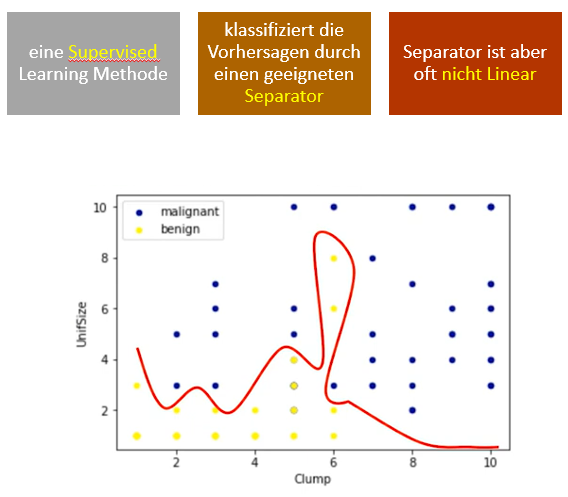

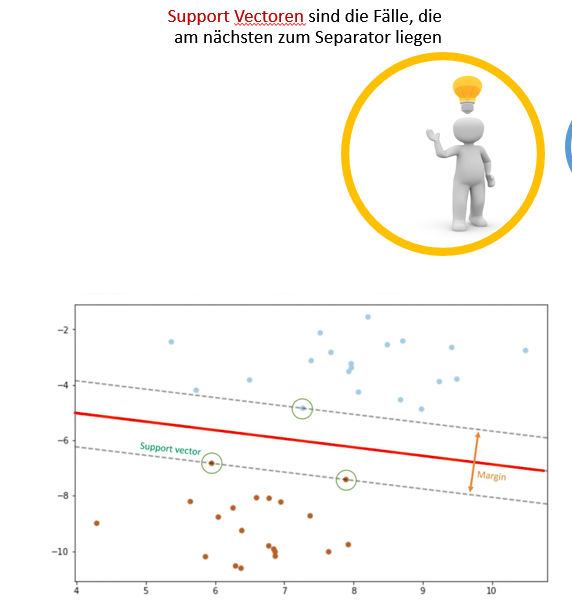

<div style="background-color:rgba(250, 250, 0, 0.1)">

---

# Aufgabe: 

Vorhersage der Weinqualität auf Grund von ``proline`` und ``hue``.

---



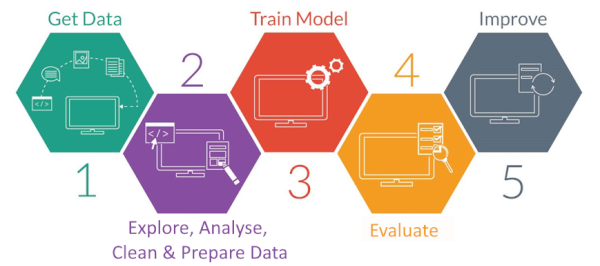

---
# 🟨 ``Schritt 1:`` Daten laden

Zuerst werden die Daten in den Hauptspeicher geladen. Im Beispiel wird die Funktion `sklearn.datasets.load_wine` verwendet.

In [ ]:
from sklearn import datasets
import pandas as pd

#-------------------------------------------------------------------------
# Laden der Daten
dfWine, target = datasets.load_wine( return_X_y=True, as_frame=True )

dfWine['class'] = target.replace({0:'class_0',1:'class_1', 2:'class_2'})

dfWine.head()

Darstellen wie die Klassen verteilt sind

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

#------------------------------------------------------------
plt.figure(figsize=(6, 4))

#------------------------------------------------------------
# Visualisieren der Daten
sns.scatterplot(data=dfWine, x='proline', y='hue', hue='class', palette='Set1')

---
# 🟨 ``Schritt 2:`` Data Preprocessing


### Daten auswählen

Erstellen eines Dataframes mit den Fetures, welche für die Vorhersage verwendet werden sollen und eines für das Feature, welches vorhergesagt werden soll.


In [ ]:
#------------------------------------------------------------
# Features auswählen
cols_x  = ['proline', 'hue']  # independent
cols_y  = 'class'             # dependent: Vorhersagen

#------------------------------------------------------------
dfLearn_X = dfWine[cols_x]
dfLearn_Y = dfWine[cols_y]

### Features Skalieren

In [ ]:
#-------------------------------------------------------------
# Führe später die Übung ein weiteres mal mit skalierten Daten durch
# ---> Dein Code 



### Trainings- und Testdaten erstellen

In [ ]:
from sklearn.model_selection import train_test_split

#------------------------------------------------------------
testsize = 0.3
dfTrain_x, dfTest_x, dfTrain_y, dfTest_y = train_test_split( dfLearn_X, dfLearn_Y,
                test_size= testsize, 
                random_state=0)

#------------------------------------------------------------
# Dataframe in Array umrechnens
train_x = dfTrain_x.values       # independent
train_y = dfTrain_y.values       # dependent

test_x  = dfTest_x.values        # independent
test_y  = dfTest_y.values        # dependent
#------------------------------------------------------------

---
# 🟨 ``Schritt 3:`` Modell erstellen und trainieren


### Modell erstellen und trainieren


SVM bietet eine große Auswahl von Methoden an, um die Daten mehrdimensional zu trennen.
Diese Methoden werden auch ``Kernel-Funktionen`` und das Trennen ``kerneling`` genannt

> Zur Auswahl stehen:
>
> ```
>  1. Linear
>  2. Polynomial
>  3. Radial basis function (RBF)
>  4. Sigmoid
> ```


Jede dieser Funktionen hat eine eigene Characteristik mit ihren Vor- und Nachteilen. Welche der Funktionen sich am Besten für die jeweiligen Daten eignet ist nicht einfach zu bestimmen. Welche dieser Methoden sich am Besten für die Daten eignet muss durch Vergleich der Ergebnisse ermittelt werden.  

Für jeden Kernel gibt es eine Reihe von Parametern mit denen dieser optimiert werden kann. Wir beschränken uns hier auf 

> ``die Regulierungsstärke C, welche einen Wert zwischen 0 und 1 annehmen kann``


Für diese Übung verwenden wir die ``RBF (Radial Basis Function)`` Kernelfunktion und einer ``Regularisierungstärke C=1``.

In [ ]:
from sklearn  import svm

#------------------------------------------------------------
# Modell erstellen und trainieren
model = svm.SVC(kernel='linear', C=1)
model.fit(train_x, train_y) 

### Vorhersagen erstellen
Erstelle mit dem trainierten Modell nun für die Trainings- und Testdaten die jeweiligen Vorhersagen.


In [ ]:
#------------------------------------------------------------
# Vorhersagen für die Trainingsdaten erstellen
pred_train_y = model.predict(train_x)

#------------------------------------------------------------
# Vorhersagen für die Testdaten erstellen
pred_y = model.predict(test_x)

Visueller Vergleich der tatsächlichen und der vorhergesagten Werte

In [ ]:
# Vergleiche die ersten 5 Werte der Testdaten mit den vorhergesagten Werten
print("Testdaten: ")
print ("Tatsächlich: ", test_y [0:5])
print ("Vorhersagen: ", pred_y [0:5])

---
# 🟨 ``Schritt 4:`` Evaluieren


## 🔷 Genauigkeit des Modells

Die Genauigkeit der Vorhersage kann mittels eines **``accuracy_score``** ermittelt werden.

In [ ]:
# Prüfen der Genauigkeit des Models
from sklearn import metrics

print("Genauigkeit der Trainingsdaten:  %.3f " %  metrics.accuracy_score(train_y, pred_train_y))
print("Genauigkeit der Testdaten:       %.3f " %  metrics.accuracy_score(test_y, pred_y))

<div style="background-color:rgba(0, 0, 250, 0.1)">

---
**Was kannst du über die Genauigkeit des Modells sagen?<br>
 Begründe deine Antwort!**<br>  
 
84% der Trainingsdaten und 80% der Testdaten werden korrekt vorhergesagt. 

Das Modell scheint sehr ausgewogen zu sein und gute Ergebnisse zu liefern. Es sollte jedoch nochoptimiert werden.

---
</div>

## 🔷 Visualisieren der Entscheidungsgrenzen


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
%matplotlib inline

#------------------------------------------------------------
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14,5))

#------------------------------------------------------------
# Entscheidungsgrenzen des Modells visualisieren
axs[0].set_title('Trainings-Accuracy', loc='left',color='r', fontsize=12)
DecisionBoundaryDisplay.from_estimator( 
            model, train_x, xlabel='proline',ylabel='hue', 
            alpha=0.5, eps=0.5, ax=axs[0], cmap = 'brg')

axs[1].set_title('Test-Accuracy', loc='left',color='r', fontsize=12)
DecisionBoundaryDisplay.from_estimator(
            model, test_x, xlabel='proline',ylabel='hue', 
            alpha=0.5, eps=0.5, ax=axs[1], cmap = 'brg')

#------------------------------------------------------------
# Tatsächliche Werte anzeigen
sns.scatterplot(x=train_x[:,0], y=train_x[:,1], hue=train_y, palette= ['b','r','g'],  ax=axs[0], hue_order=model.classes_)
sns.scatterplot(x=test_x [:,0], y=test_x [:,1], hue=test_y,  palette= ['b','r','g'],  ax=axs[1], hue_order=model.classes_)

plt.show()

---

# 🟨 Praxistest



In [ ]:
# Testdaten generieren
proline = 800
hue  = 0.75
test_data = [[proline, hue]]

# Vorhersage erstellen
wclass = model.predict(test_data)

# Species ausgeben
print("Vorhersage der Klasse: ", wclass[0])

Das Erstellen einer ``Wahrscheinlichkeit der Vorhersage`` führt bei SVM zu starken perormance Einbussen und wird deshalb meistens nicht durchgeführt!

---
# 🟨 ``Schritt 5:`` Improve



### ELLBOW-Methode: ``Finden der besten Genauigkeit``


Bei Decision Trees kann das Modell durch den gewählten ``Kernel`` und durch die gewählte Regulierungsstärke ``C`` optimiert werden.

In [ ]:
import numpy as np

training_accuracy = []
test_accuracy = []

# Bereich für Regulierung festlegen
test_range = np.linspace(0.1, 1, 20)
test_kernel='rbf'
#test_kernel='linear'

for c in test_range :    
    # Model trainieren 
    model = svm.SVC(kernel=test_kernel, C=c)
    model.fit(train_x,train_y)

    # Trainingsgenauigkeit bestimmen
    pred  = model.predict(train_x)
    score = metrics.accuracy_score(train_y, pred)
    training_accuracy.append(score)

    # Testgenauigkeit bestimmen
    pred  = model.predict(test_x)
    score = metrics.accuracy_score(test_y, pred)
    test_accuracy.append(score)

best_C      = test_range[ np.argmax(test_accuracy) ]
best_score  = max(test_accuracy)

# Ausgabe aller Scores 
print( "Höchste TEST-Genauigkeit ist %.3f" % best_score, "mit C=", best_C) 

#### Verlauf der Genauigkeit
Damit wir die Genauigkeit der verschiedenen Parameter besser vergleichen können, geben wir sie als Graph aus.

In [ ]:
plt.plot(test_range, training_accuracy, label="Trainings-Genauigkeit")
plt.plot(test_range, test_accuracy,     label="Test-Genauigkeit")
plt.ylabel("Accuracy")
plt.xlabel("C")
plt.legend()
#plt.savefig('knn_compare_model')

plt.show()